In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import math

In [ ]:
# `Question: 1` A company wants to estimate the average time spent by customers on their website per session. They collect a random sample of 100 customers 
# and find that the sample mean time spent is 4.5 minutes with a sample standard deviation of 1.2 minutes. Calculate a 99% confidence interval for the true
# population mean time spent on the website per session.

In [ ]:
n = 100
x = 4.5
s = 1.2
CL = 99
alpha = 0.01
CI = 0

t_values = stats.t.ppf(1 - alpha/2, n-1)
# critical_values
margin_of_errors = t_values * (s / np.sqrt(n))

upper_limit = x + margin_of_errors
lower_limit = x - margin_of_errors

print('Limit is',lower_limit,upper_limit,'with Confidence level',CL,'%')


Limit is 4.184831345126301 4.815168654873699 with Confidence level 99 %


np.float64(0.31516865487369927)

In [ ]:

# `Question 2:` A car manufacturer is interested in estimating the mean gas mileage of their new SUV. A sample of 25 SUVs is taken, and their mean gas mileage 
# is found to be 28.6 miles per gallon with a standard deviation of 2.8 miles per gallon. Calculate a 95% confidence interval for the true mean gas mileage of 
# the SUV.

In [24]:
n = 25 #number of suvs
x = 28.6 #miles per gallon
s = 2.8 #miles per gallon
CL = 95
alpha = 0.05

t_values = stats.t.ppf(1 - alpha/2, n-1)
# critical_values
margin_of_errors = t_values * (s / np.sqrt(n))

upper_limit = x + margin_of_errors
lower_limit = x - margin_of_errors

print('Population Paramter Value lies in [',lower_limit,upper_limit,'] with Confidence level',CL,'%')


Population Paramter Value lies in [ 27.44421680548831 29.755783194511693 ] with Confidence level 95 %


`Question -3:` Dataset - India temperature dataset.

Data link: https://drive.google.com/file/d/1whb8Rjdk9TBKOwVi8NwZD1Tc8Tdv7iEc/view?usp=share_link

Kaggle Link : (Just take IND data for this question, have to apply filtering). https://www.kaggle.com/datasets/berkeleyearth/climate-change-earth-surface-temperature-data

A climate research organization wants to estimate the average temperature of a certain country. They collect temperature data for 2613 days but due to certain limitations, they only have information about the average temperature for 2508 days. The organization assumes that the population follows a normal distribution and wants to estimate the population mean temperature with a 95% confidence interval.

* Standard deviation is assumed as given data standard deviation. z Procedure
* Standard deviation is not given. Apply t Procedure

In [ ]:



df_india = pd.read_csv('Data\ind_temp.csv')
df_india.head()

# df_country = pd.read_csv('D:\Education\Extra\Machine Learning\DSMP 1.0\Statisctis\Exercise\Data\Climate change\GlobalLandTemperaturesByCountry.csv')
# df_country.head()

df_india.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1796-01-01,17.044,2.044,India
1,1796-02-01,19.193,1.359,India
2,1796-03-01,22.319,2.125,India
3,1796-04-01,27.233,1.510,India
4,1796-05-01,30.035,1.338,India


<Axes: ylabel='Density'>

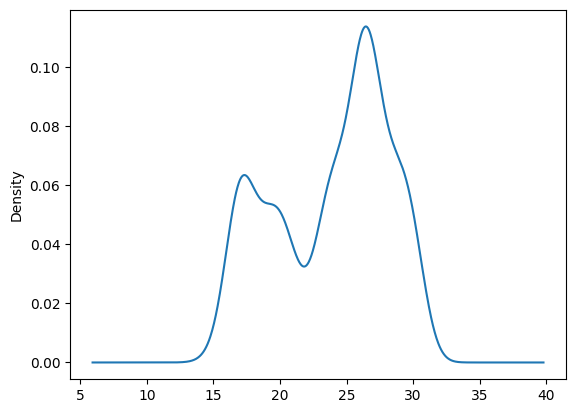

In [ ]:
#data of the population

pop_std = df_india['AverageTemperature'].std()

df_india['AverageTemperature'].plot(kind='kde')

<Axes: ylabel='Density'>

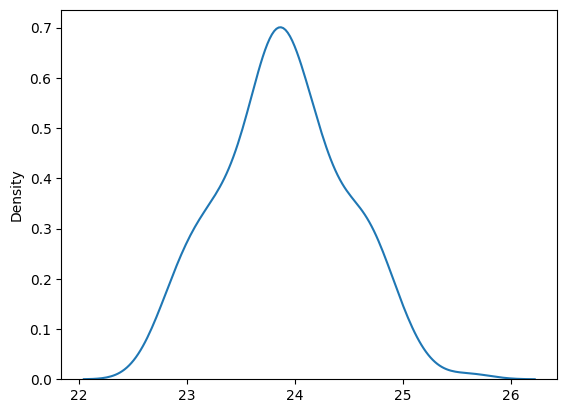

In [53]:
#take the sample of the data

sample = []

n = 50

for i in range(200):
    sample.append(df_india['AverageTemperature'].sample(50).tolist())    

sample = np.array(sample)
sample_temp_mean = sample.mean(axis=1)
sample_temp_std = sample.std(axis=1)

sns.kdeplot(sample_temp_mean)
# sns.kdeplot(sample_temp_std)

In [59]:
#standard deviation is not available - t method
n = 50
CL = 0.95 
alpha = 1+CL
x = sample_temp_mean.mean()
s = sample_temp_std.mean()
t_values = stats.t.ppf(alpha/2, n-1)
# critical_values
margin_of_errors = t_values * (s / np.sqrt(n))

upper_limit = x + margin_of_errors
lower_limit = x - margin_of_errors

print('temperature parameter value of India lies in [',lower_limit,upper_limit,'] with Confidence level',CL,'%')
print('Actual mean of the population',df_india['AverageTemperature'].mean())

temperature parameter value of India lies in [ 22.676468377644955 25.113768222355052 ] with Confidence level 0.95 %
Actual mean of the population 23.873789473684212


In [60]:
#standard deviation is available - z method
n = 50
CL = 0.95 
alpha = 1+CL
x = sample_temp_mean.mean()
sigma = df_india['AverageTemperature'].std()
z_values = stats.norm.ppf(alpha/2)

# critical_values
margin_of_errors = z_values * (sigma/ np.sqrt(n))

upper_limit = x + margin_of_errors
lower_limit = x - margin_of_errors

print('temperature parameter value of India lies in [',lower_limit,upper_limit,'] with Confidence level',CL,'%')
print('Actual mean of the population',df_india['AverageTemperature'].mean())

temperature parameter value of India lies in [ 22.696086640013405 25.094149959986602 ] with Confidence level 0.95 %
Actual mean of the population 23.873789473684212


`Question 5:` BMW Dataset : https://drive.google.com/file/d/18amVv1WKKHEmwyvVy0RuXp4A6xrGOelc/view?usp=share_link



* Task 1:
The sales manager of a used car company wants to know what is the average selling price of all the used bmw cars.
The analyst can collect only a sample of sales of 500 cars in the area. Since this estimate is going to be used by the company to strategize sales of his company, the sample mean should be a good approximation of all the account.
What level of confidence is the sales manager going to be satisfied with? What +/- interval number is going to be acceptable?

* Task 2:
In addition to the price of the car, the manager also wants to now know the average mileage that the car has been driven. But the manager does not have the population standard deviation for the mileage. But the mileage data is available only from the 25 cars that they have sold so far.
How do the analyst approach this problem to calculate 95% confidence interval, with only 25 samples?

* Task 3:
The manager is not happy with both the intervals (intervals from task 1 and 2) as the interval for the confidence is very high. The manager now asks the analyst to estimate the average price of the car (similar to task 1) but within a bound of 750 from the mean with 95% condidence level. How many sample does the analyst have to collect to arrive at this confidence interval level?

* Task 4:
Conversely, after the analyst started collecting the data, after a week he was only able to collect for 420 samples, though he needs 540 samples for Bound of 1,000, if he has to do the analysis now, what is the best interval he can acheive for 95% confidence levels?

* Task 1:
The sales manager of a used car company wants to know what is the average selling price of all the used bmw cars.
The analyst can collect only a sample of sales of 500 cars in the area. Since this estimate is going to be used by the company to strategize sales of his company, the sample mean should be a good approximation of all the account.
What level of confidence is the sales manager going to be satisfied with? What +/- interval number is going to be acceptable?

In [63]:
df = pd.read_csv('Data/bmw.csv')
df.shape

(10781, 9)

<Axes: ylabel='Density'>

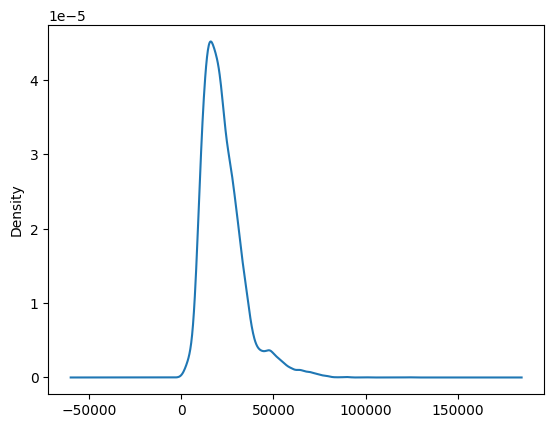

In [62]:
df['price'].plot(kind='kde')

In [126]:
#now sample
n = 500
sample_price = []

# for i in range(200):
#     sample_price.append(df['price'].sample(n).tolist())
    

# sample_price = np.array(sample_price)

# sample_price_mean = sample_price.mean(axis=1)
# sample_price_std = sample_price.std(axis=1)

sample_price = df['price'].sample(n,random_state=42)
sample_price_mean = sample_price.mean()
sample_price_std = sample_price.std()

In [88]:
# sns.displot(sample_price_mean,kind='kde')

In [127]:
#Confidence level with 90% t approximation

n = 500
x = sample_price_mean
s = sample_price_std 
CL = 90
alpha = (1 + CL/100)/2

t_value = stats.t.ppf(alpha,df = n-1)

upper_value = x + t_value*s/np.sqrt(n)
lower_value = x - t_value*s/np.sqrt(n)

print('Price Parameter of BMW salling price is [',lower_value,upper_value,'] with confidence level',CL,'%')
print('Actual BMW selling mean price',df['price'].mean())

Price Parameter of BMW salling price is [ 22202.001098024484 23820.33490197552 ] with confidence level 90 %
Actual BMW selling mean price 22733.408867452


* Task 2:
In addition to the price of the car, the manager also wants to now know the average mileage that the car has been driven. But the manager does not have the population standard deviation for the mileage. But the mileage data is available only from the 25 cars that they have sold so far.
How do the analyst approach this problem to calculate 95% confidence interval, with only 25 samples?

In [140]:
sample = df.sample(n=25,random_state=1)
sample.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
3840,X5,2017,35470,Automatic,47717,Diesel,235,42.8,3.0
7757,5 Series,2015,15490,Automatic,45000,Diesel,160,51.4,3.0
10325,i3,2016,17000,Automatic,41063,Other,0,470.8,0.6
685,1 Series,2015,10991,Semi-Auto,45000,Diesel,20,72.4,1.5
1947,X1,2017,21050,Semi-Auto,18099,Diesel,145,57.6,2.0


In [141]:
sample_mileage_mean = sample['mileage'].mean()
sample_mileage_std = sample['mileage'].std()
sample_mileage_mean,sample_mileage_std

(np.float64(25148.68), np.float64(17421.996206233085))

In [142]:
n = 25
CL= 95
x = sample_mileage_mean
s = sample_mileage_std
alpha = 1+CL/100


t_value = stats.t.ppf(alpha/2,df=n-1)
lower_value = x - t_value*s/np.sqrt(n)
upper_value = x + t_value*s/np.sqrt(n)
print('Mileage population parameter of BMW is [',lower_value,upper_value,'] with confidence level',CL,'%')
print('Actual BMW mileage mean price',df['mileage'].mean())

Mileage population parameter of BMW is [ 17957.233417853342 32340.12658214666 ] with confidence level 95 %
Actual BMW mileage mean price 25496.986550412763


* Task 3:
The manager is not happy with both the intervals (intervals from task 1 and 2) as the interval for the confidence is very high. The manager now asks the analyst to estimate the average price of the car (similar to task 1) but within a bound of 750 from the mean with 95% condidence level. How many sample does the analyst have to collect to arrive at this confidence interval level?

#### Task 3:

To calculate the required sample size for price estimation with in 750 margin, we need to use the following formula:

### The size of the sample is affected by parameters such as:
- Bound that we need our interval to be within. This is represented by B. In question 3, B = 750
- The confidence level (1−𝛼). In question 3 this is 95%
- What is the estimate of variance (of standard deviation) of the population?

##### The minimum number of required samples to estimate the population mean μ is:

$$ n = \dfrac{Z^2 _{\alpha / 2} \sigma^2}{B^2} $$

Where,
n = sample size
z = z-score for the desired confidence level (95%)
std = standard deviation of the population (unknown in this case)
B = margin of error (750)

To calculate the sample size, we need to estimate the standard deviation. We can use the standard deviation of the sample as an estimate for the population standard deviation.

First, let's calculate the sample standard deviation:

In [145]:
n= 50
sample = []
for i in range(300):
    sample.append(df.sample(50)['price'].tolist())
    
sample = np.array(sample)
sample_std = sample.std(axis=1)
sample_mean = sample.mean(axis=1)

In [147]:
sigma = sample_std.mean()
B = 750
CL = 95
zalpha_2 = stats.norm.ppf(0.975)

n = ((zalpha_2*zalpha_2)*(sigma*sigma))/(B*B)
n


np.float64(827.1550433103422)

* Task 4:
Conversely, after the analyst started collecting the data, after a week he was only able to collect for 420 samples, though he needs 540 samples for Bound of 1,000, if he has to do the analysis now, what is the best interval he can acheive for 95% confidence levels?

In [150]:
sigma = df.sample(420)['price'].std()
CL = 95
zalpha_2 = stats.norm.ppf(0.975)
n = 420
B = (zalpha_2*sigma)/np.sqrt(n)

B

np.float64(1177.159781690471)

In [4]:
#standard deviation is available - z method
n = 36
x = 1980
miyu = 2000
CL = 0.95 
alpha = 1+CL
sigma = 100
z_values = stats.norm.ppf(alpha/2)

# critical_values
margin_of_errors = z_values * (sigma/ np.sqrt(n))

upper_limit = x + margin_of_errors
lower_limit = x - margin_of_errors

print('temperature parameter value of India lies in [',lower_limit,upper_limit,'] with Confidence level',CL,'%')

temperature parameter value of India lies in [ 1947.333933590999 2012.666066409001 ] with Confidence level 0.95 %
